# Biodiversity Project: Endangered Species in Different Parks 
 Data Source: National Parks Service

## Import Libraries and Adjust Output Parameters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)  # No limit on the number of columns
pd.set_option('display.width', 1000)        # Set a larger display width for horizontal output
pd.set_option('display.max_colwidth', None) # Avoid truncation of column content

## Load observations.csv and species_info.csv

In [2]:
si_df = pd.read_csv('species_info.csv')
obs_df = pd.read_csv('observations.csv')

print('Species Info:')
print(si_df.head(), '\n\n')

print('Observations:')
print(obs_df.head())

Species Info:
  category                scientific_name                                                    common_names conservation_status
0   Mammal  Clethrionomys gapperi gapperi                                        Gapper's Red-Backed Vole                 NaN
1   Mammal                      Bos bison                                           American Bison, Bison                 NaN
2   Mammal                     Bos taurus  Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle                 NaN
3   Mammal                     Ovis aries               Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN
4   Mammal                 Cervus elaphus                                                   Wapiti Or Elk                 NaN 


Observations:
            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains Nati

## Explore Data

### species_info.csv

In [3]:
print('Species Info')
print(si_df.describe(), '\n')

print(f'Rows: {si_df.shape[0]} \nColumns: {si_df.shape[1]}')


Species Info
              category    scientific_name        common_names conservation_status
count             5824               5824                5824                 191
unique               7               5541                5504                   4
top     Vascular Plant  Castor canadensis  Brachythecium Moss  Species of Concern
freq              4470                  3                   7                 161 

Rows: 5824 
Columns: 4


In [4]:
# examining species names
print('# in each Species Category')
print(si_df['category'].value_counts(), '\n')
print(si_df[si_df['scientific_name'] =='Castor canadensis'], '\n')

# examing NaN values
missing_vals_si = si_df.isnull().sum()
print(f'Missing Values species_info.csv:\n{missing_vals_si}, \n')

# in each Species Category
category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64 

     category    scientific_name             common_names conservation_status
49     Mammal  Castor canadensis  American Beaver, Beaver                 NaN
3050   Mammal  Castor canadensis          American Beaver                 NaN
4475   Mammal  Castor canadensis                   Beaver                 NaN 

Missing Values species_info.csv:
category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64, 



### observations.csv

In [5]:
print('Observations DataFrame Stats')
print(obs_df.describe(), '\n')

print(f'Rows: {obs_df.shape[0]} \nColumns: {obs_df.shape[1]} \n')

print(f'Total Number of Observations: {obs_df['observations'].sum()} \n')


missing_vals_obs = obs_df.isnull().sum()
print(f'Missing Values:\n{missing_vals_obs}, \n')

Observations DataFrame Stats
       observations
count  23296.000000
mean     142.287904
std       69.890532
min        9.000000
25%       86.000000
50%      124.000000
75%      195.000000
max      321.000000 

Rows: 23296 
Columns: 3 

Total Number of Observations: 3314739 

Missing Values:
scientific_name    0
park_name          0
observations       0
dtype: int64, 



### Observations per Park

DataFrame grouped by Park Name: 

                             park_name  observations
0                  Bryce National Park        576025
1  Great Smoky Mountains National Park        431820
2            Yellowstone National Park       1443562
3               Yosemite National Park        863332


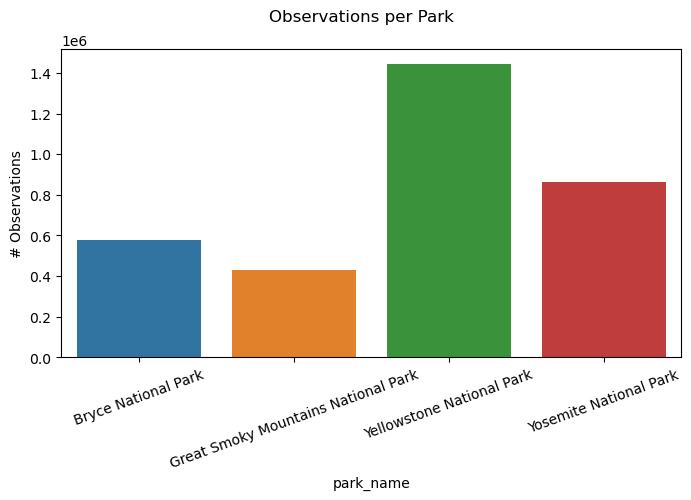

<Figure size 640x480 with 0 Axes>

In [6]:
# Number of Observations per Park in new Dataframe
park_df = obs_df.groupby('park_name').sum().reset_index()
park_df = park_df.drop(columns = ['scientific_name'])
print('DataFrame grouped by Park Name: \n')
print(park_df.head())

# Barplot
plt.figure(figsize=(8,4)).suptitle('Observations per Park')
sns.barplot(data=park_df, x='park_name', y='observations', hue='park_name')
plt.ylabel('# Observations')
plt.xticks(rotation=20)
plt.show()
plt.clf()


# Analysis

### Distribution of Conservation Statuses for All Species

#### Per Observation

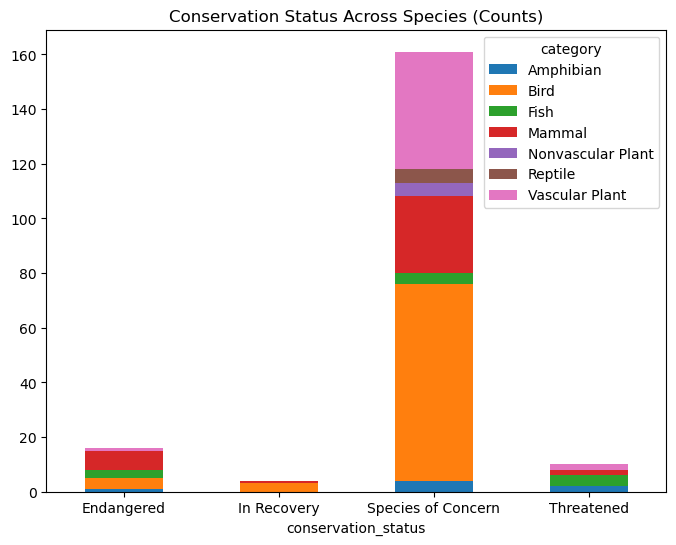

category             Amphibian  Bird  Fish  Mammal  Nonvascular Plant  Reptile  Vascular Plant
conservation_status                                                                           
Endangered                 1.0   4.0   3.0     7.0                NaN      NaN             1.0
In Recovery                NaN   3.0   NaN     1.0                NaN      NaN             NaN
Species of Concern         4.0  72.0   4.0    28.0                5.0      5.0            43.0
Threatened                 2.0   NaN   4.0     2.0                NaN      NaN             2.0 

category             Amphibian  Bird  Fish  Mammal  Nonvascular Plant  Reptile  Vascular Plant
conservation_status                                                                           
Endangered                 1.0   4.0   3.0     7.0                0.0      0.0             1.0
In Recovery                0.0   3.0   0.0     1.0                0.0      0.0             0.0
Species of Concern         4.0  72.0   4.0    28

<Figure size 640x480 with 0 Axes>

In [7]:
# Stacked bar chart to see distribution of conservation status across all species
conservation_statusdf = si_df[si_df.conservation_status != "No Intervention"]\
    .groupby(["conservation_status", "category"])['scientific_name']\
    .count()\
    .unstack()
conservation_statusdf.plot(kind = 'bar', figsize=(8,6), stacked=True)
plt.title('Conservation Status Across Species (Counts)')
plt.xticks(rotation=0)
plt.show()
plt.clf()

print(conservation_statusdf.head(), '\n')
# clean NaN values
conservation_statusdf = conservation_statusdf.fillna(0)
print(conservation_statusdf.head(), '\n')


#### Proportionally

Proportions 

category             Amphibian  Bird  Fish  Mammal  Nonvascular Plant  Reptile  Vascular Plant
conservation_status                                                                           
Endangered                 6.2  25.0  18.8    43.8                0.0      0.0             6.2
In Recovery                0.0  75.0   0.0    25.0                0.0      0.0             0.0
Species of Concern         2.5  44.7   2.5    17.4                3.1      3.1            26.7
Threatened                20.0   0.0  40.0    20.0                0.0      0.0            20.0


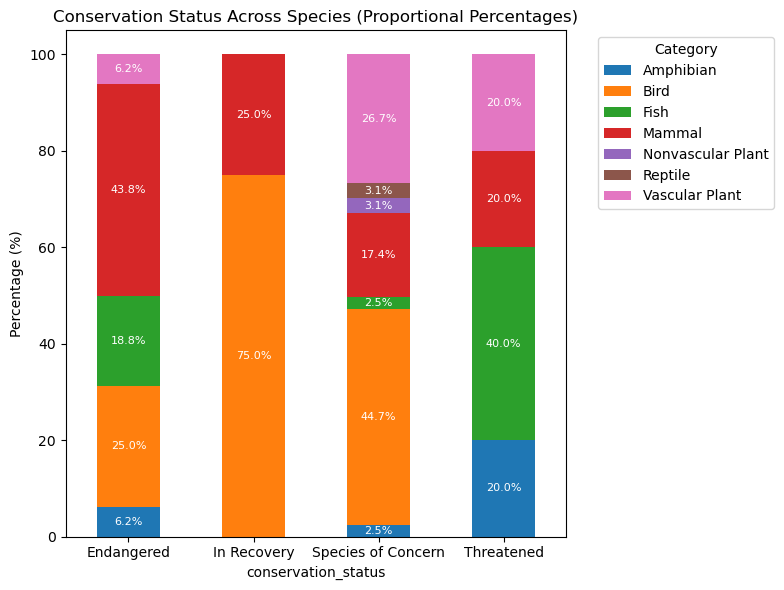

In [8]:
# create a df of proportions to show each species' percentage of the conservation status data
print(f'Proportions \n')
totals = conservation_statusdf.sum(axis=1)

proportionsdf = round(conservation_statusdf.div(totals, axis=0).mul(100, axis=0), 1)
# proportionsdf['total'] = proportionsdf.sum(axis=1)
print(proportionsdf)

# Create a bar plot with proportional values
ax = proportionsdf.plot(kind='bar', stacked=True, figsize=(8, 6))

for i, bar_group in enumerate(ax.containers):
    for bar in bar_group:
        if bar.get_height() > 0:  # Avoid showing labels for 0 heights
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # Center of the bar segment
                bar.get_y() + bar.get_height() / 2,  # Middle of the segment
                f"{bar.get_height():.1f}%",  # Format percentage
                ha='center', va='center', fontsize=8, color='white'
            )

plt.ylabel('Percentage (%)')
plt.title('Conservation Status Across Species (Proportional Percentages)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()


### Are certain types of species more likely to be endangered?

Clean conservation status column within the species_info data frame in order to represent non-protected species.

In [9]:
# cleaning si_df.conservation_status to fill NaN with No Intervention to better
# represent the population in plotting this column

si_df.conservation_status = si_df.conservation_status.fillna('No Intervention')
print(si_df.head())

  category                scientific_name                                                    common_names conservation_status
0   Mammal  Clethrionomys gapperi gapperi                                        Gapper's Red-Backed Vole     No Intervention
1   Mammal                      Bos bison                                           American Bison, Bison     No Intervention
2   Mammal                     Bos taurus  Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle     No Intervention
3   Mammal                     Ovis aries               Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)     No Intervention
4   Mammal                 Cervus elaphus                                                   Wapiti Or Elk     No Intervention


Create boolean is_protected column.

In [10]:
si_df['is_protected'] = si_df['conservation_status'] != 'No Intervention'
print(si_df.head())

  category                scientific_name                                                    common_names conservation_status  is_protected
0   Mammal  Clethrionomys gapperi gapperi                                        Gapper's Red-Backed Vole     No Intervention         False
1   Mammal                      Bos bison                                           American Bison, Bison     No Intervention         False
2   Mammal                     Bos taurus  Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle     No Intervention         False
3   Mammal                     Ovis aries               Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)     No Intervention         False
4   Mammal                 Cervus elaphus                                                   Wapiti Or Elk     No Intervention         False


Create a boolean 'is_protected' Data Frame in order to show Intervention vs non-Intervention proportionally.

In [11]:
is_protected_df = si_df.groupby(['category', 'is_protected'])\
                        .scientific_name.nunique()\
                        .reset_index()\
                        .pivot(columns='is_protected',
                                      index='category',
                                      values='scientific_name')\
                        .reset_index()
is_protected_df.columns = ['category', 'not_protected', 'protected']
print(is_protected_df)

# Create a new DataFrame with the calculated percentage
is_protected_df_percent = is_protected_df.assign(
    percentage_protected=is_protected_df['protected'] / 
    (is_protected_df['protected'] + is_protected_df['not_protected']) * 100
)

# Print the result
print(is_protected_df_percent)

            category  not_protected  protected
0          Amphibian             72          7
1               Bird            413         75
2               Fish            115         11
3             Mammal            146         30
4  Nonvascular Plant            328          5
5            Reptile             73          5
6     Vascular Plant           4216         46
            category  not_protected  protected  percentage_protected
0          Amphibian             72          7              8.860759
1               Bird            413         75             15.368852
2               Fish            115         11              8.730159
3             Mammal            146         30             17.045455
4  Nonvascular Plant            328          5              1.501502
5            Reptile             73          5              6.410256
6     Vascular Plant           4216         46              1.079305


#### Most Endangered Species by Category

Create a Data Frame for ONLY endangered species in order to derive the proportion of 'endangered species category' out of 'total endangered species'. 

In [12]:
# making a df for endangered species
endangered_df = si_df[si_df['conservation_status'] == 'Endangered']
# print(endangered_df, '\n')

# create df for endangered species per category
per_cat_df = endangered_df['category'].value_counts().reset_index()
print(f'# of Endangered Species per Category \n{per_cat_df.head()} \n')

total = per_cat_df['count'].sum()
per_cat_df['percentage'] = round(per_cat_df['count'] / total, 2)*100
print(f'Percentage of Endangered Species per Category \n{per_cat_df}')

# of Endangered Species per Category 
         category  count
0          Mammal      7
1            Bird      4
2            Fish      3
3  Vascular Plant      1
4       Amphibian      1 

Percentage of Endangered Species per Category 
         category  count  percentage
0          Mammal      7        44.0
1            Bird      4        25.0
2            Fish      3        19.0
3  Vascular Plant      1         6.0
4       Amphibian      1         6.0


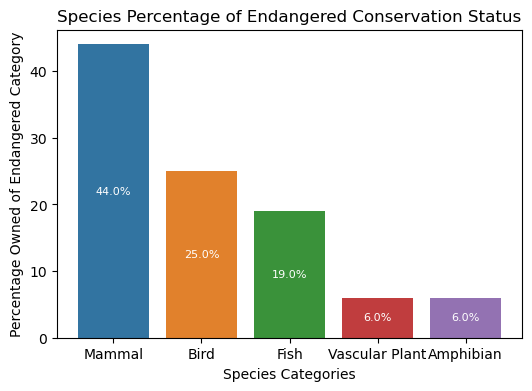

<Figure size 640x480 with 0 Axes>

In [13]:
# Bar plot of endangered species per category
plt.figure(figsize=(6,4))
ax = sns.barplot(data=per_cat_df, x='category', y='percentage', hue='category')
ax.plot(type='bar', hue='category')
plt.xlabel('Species Categories')
plt.ylabel('Percentage Owned of Endangered Category')

for i, bar_group in enumerate(ax.containers):
    for bar in bar_group:
        if bar.get_height() > 0:  # Avoid showing labels for 0 heights
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # Center of the bar segment
                bar.get_y() + bar.get_height() / 2,  # Middle of the segment
                f"{bar.get_height():.1f}%",  # Format percentage
                ha='center', va='center', fontsize=8, color='white'
            )
plt.title('Species Percentage of Endangered Conservation Status')            
plt.xticks(rotation=0)
plt.show()
plt.clf()



### Do species differ significantly across specific conservation statuses?

#### Mammals vs Birds

Implement a Chi-Square test to compare Mammal and Bird categories. This will evaluate the  significance of the difference in the distribution of their conservation status'.

~ Contingency Table Format

||Endangered|In Recovery|No Intervention|Species of Concern|Threatened|
|-|-|-|-|-|-|
|Mammal|?|?|?|?|?
|Bird|?|?|?|?|?

In [14]:
# create a data frame to aggregate conservation_status per species category
status_byspecies_df = si_df.groupby(['category', 'conservation_status']).size().unstack(fill_value=0)

print(f'~status_byspecies_df~ \n{status_byspecies_df}', '\n')

#create contingency tables
print('~Mammal vs Bird Contingency Table~')
mammal_bird_contingency = status_byspecies_df.loc[['Mammal', 'Bird']]
print(mammal_bird_contingency)

~status_byspecies_df~ 
conservation_status  Endangered  In Recovery  No Intervention  Species of Concern  Threatened
category                                                                                     
Amphibian                     1            0               73                   4           2
Bird                          4            3              442                  72           0
Fish                          3            0              116                   4           4
Mammal                        7            1              176                  28           2
Nonvascular Plant             0            0              328                   5           0
Reptile                       0            0               74                   5           0
Vascular Plant                1            0             4424                  43           2 

~Mammal vs Bird Contingency Table~
conservation_status  Endangered  In Recovery  No Intervention  Species of Concern  Threatened


Run Chi-Square Test and take p-value results to establish level of significance.

In [15]:
chi2_mammal_bird, pval_mammal_bird, _, _ = chi2_contingency(mammal_bird_contingency)
print(f'Mammal vs Bird pval (less than .05 = statistical significant difference): {pval_mammal_bird}')


Mammal vs Bird pval (less than .05 = statistical significant difference): 0.022085036273887457


Mammal vs Bird Visualization

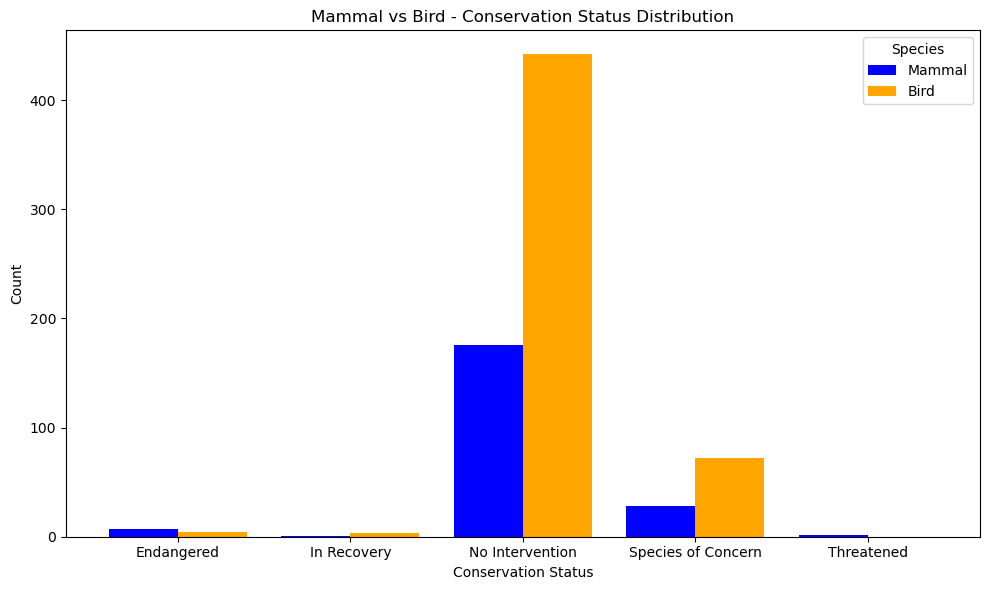

In [16]:
mammal_bird_contingency.T.plot(kind='bar', figsize=(10, 6), width=0.8, color=['blue', 'orange'])
plt.title('Mammal vs Bird - Conservation Status Distribution')
plt.ylabel('Count')
plt.xlabel('Conservation Status')
plt.xticks(rotation=0)
plt.legend(title="Species")
plt.tight_layout()
plt.show()

#### Conservation Status: Mammals vs Reptiles
Contingency Table

In [17]:
#create contingency tables
print('~Mammal vs Reptile Contingency Table~')
mammal_reptile_contingency = status_byspecies_df.loc[['Mammal', 'Reptile']]
print(mammal_reptile_contingency)

~Mammal vs Reptile Contingency Table~
conservation_status  Endangered  In Recovery  No Intervention  Species of Concern  Threatened
category                                                                                     
Mammal                        7            1              176                  28           2
Reptile                       0            0               74                   5           0


Chi-Square Test

In [18]:
chi2_mammal_reptile, pval_mammal_reptile, _, _ = chi2_contingency(mammal_reptile_contingency)
print(f'Mammal vs Reptile pval (less than .05 = significant statistical difference): {pval_mammal_reptile}')

Mammal vs Reptile pval (less than .05 = significant statistical difference): 0.14059188116790175


Visualization

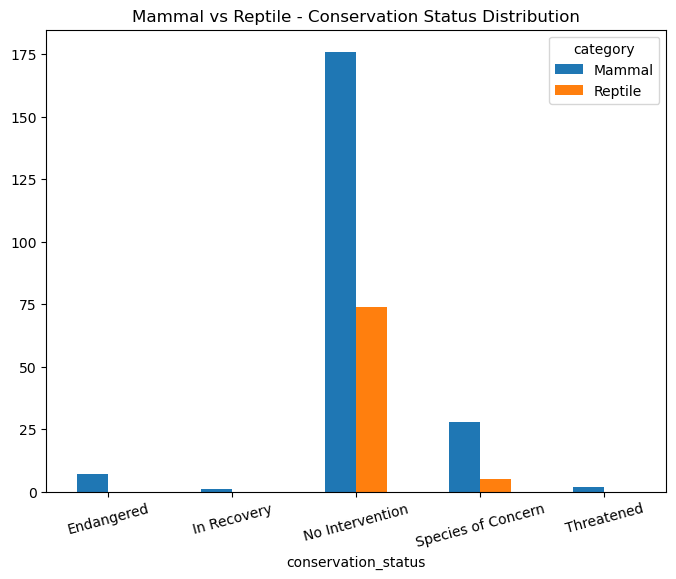

<Figure size 640x480 with 0 Axes>

In [19]:
mammal_reptile_contingency.T.plot(kind='bar', figsize=(8, 6))
plt.title('Mammal vs Reptile - Conservation Status Distribution')
plt.xticks(rotation=15)
plt.show()
plt.clf()

### Do species differ significantly in the overall likelihood of being protected?

Protection Status: Mammals vs Birds

||not protected|protected|
|-|-|-|
|Mammal|?|?|
|Bird|?|?|

Contingency Table and Chi-Square p-value

In [20]:
protection_mammal_bird_contingency = is_protected_df.set_index('category').loc[['Mammal', 'Bird']]
print(protection_mammal_bird_contingency)

chi2_contingency(protection_mammal_bird_contingency)

          not_protected  protected
category                          
Mammal              146         30
Bird                413         75


Chi2ContingencyResult(statistic=0.16170148316545574, pvalue=0.6875948096661336, dof=1, expected_freq=array([[148.1686747,  27.8313253],
       [410.8313253,  77.1686747]]))

Visualization

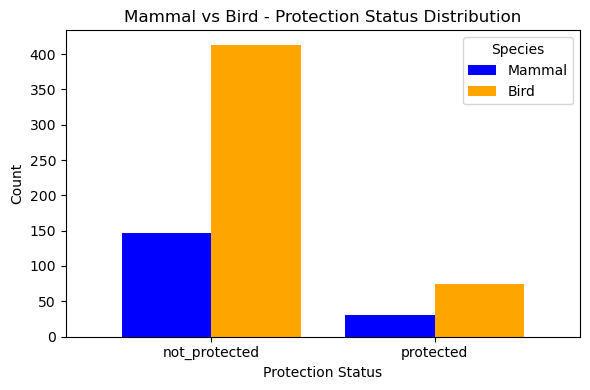

In [21]:
protection_mammal_bird_contingency.T.plot(kind='bar', figsize=(6, 4), width=0.8, color=['blue', 'orange'])
plt.title('Mammal vs Bird - Protection Status Distribution')
plt.ylabel('Count')
plt.xlabel('Protection Status')
plt.xticks(rotation=0)
plt.legend(title="Species")
plt.tight_layout()
plt.show()

Protection Status: Mammals vs Reptiles

In [22]:
protection_mammal_reptile_contingency = is_protected_df.set_index('category').loc[['Mammal', 'Reptile']]
print(protection_mammal_reptile_contingency)

chi2_contingency(protection_mammal_reptile_contingency)

          not_protected  protected
category                          
Mammal              146         30
Reptile              73          5


Chi2ContingencyResult(statistic=4.289183096203645, pvalue=0.038355590229699, dof=1, expected_freq=array([[151.7480315,  24.2519685],
       [ 67.2519685,  10.7480315]]))

Visualization

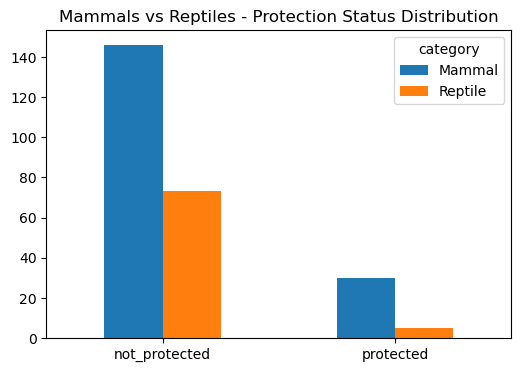

<Figure size 640x480 with 0 Axes>

In [23]:
protection_mammal_reptile_contingency.T.plot(kind='bar', figsize=(6,4))
plt.title('Mammals vs Reptiles - Protection Status Distribution')
plt.xticks(rotation=0)
plt.show()
plt.clf()

# Conclusions